---
Author: The Tuan Trinh \
Date: 01/06/2026
---

In [1]:
import os
import platform
print("=" * 100)
print("OS Name:", os.name)
print("System:", platform.system())
print("Release:", platform.release())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Platform:", platform.platform())

print("\nEnvironment Variables (sample):")
for key, value in list(os.environ.items())[:15]:
    print(f"{key} = {value}")

OS Name: nt
System: Windows
Release: 10
Machine: AMD64
Processor: Intel64 Family 6 Model 142 Stepping 12, GenuineIntel
Platform: Windows-10-10.0.26200-SP0

Environment Variables (sample):
ALLUSERSPROFILE = C:\ProgramData
APPDATA = C:\Users\Admin\AppData\Roaming
APPLICATION_INSIGHTS_NO_STATSBEAT = true
CHROME_CRASHPAD_PIPE_NAME = \\.\pipe\crashpad_9744_ZGSXKUMXDBQNQZJY
COMMONPROGRAMFILES = C:\Program Files\Common Files
COMMONPROGRAMFILES(X86) = C:\Program Files (x86)\Common Files
COMMONPROGRAMW6432 = C:\Program Files\Common Files
COMPUTERNAME = PMH
COMSPEC = C:\Windows\system32\cmd.exe
CONDA_DEFAULT_ENV = PMH
CONDA_EXE = C:\Users\Admin\miniconda3\Scripts\conda.exe
CONDA_PREFIX = C:\Users\Admin\miniconda3\envs\PMH
CONDA_PROMPT_MODIFIER = (PMH) 
CONDA_PYTHON_EXE = C:\Users\Admin\miniconda3\python.exe
CONDA_ROOT = C:\Users\Admin\miniconda3


In [2]:
platform.python_version()

'3.10.20'

# Lab 8 - Image Thresholding

## Simple Thresholding


In [3]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
h, w = 132, 129
x = np.linspace(0, 255, w, dtype=np.uint8)
img = np.tile(x, (h, 1))

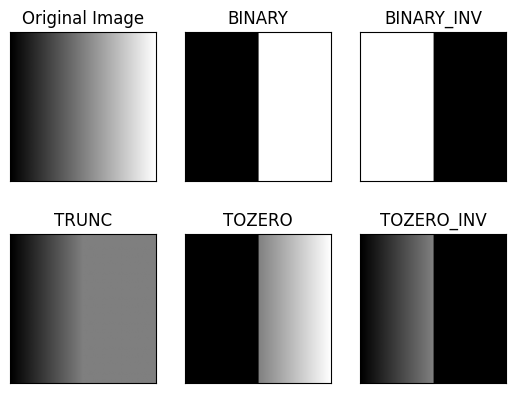

In [4]:
ret,thresh1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
ret,thresh2 = cv.threshold(img,127,255,cv.THRESH_BINARY_INV)
ret,thresh3 = cv.threshold(img,127,255,cv.THRESH_TRUNC)
ret,thresh4 = cv.threshold(img,127,255,cv.THRESH_TOZERO)
ret,thresh5 = cv.threshold(img,127,255,cv.THRESH_TOZERO_INV)
 
titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
 
for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray',vmin=0,vmax=255)
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
 
plt.show()

## Adaptive Thresholding


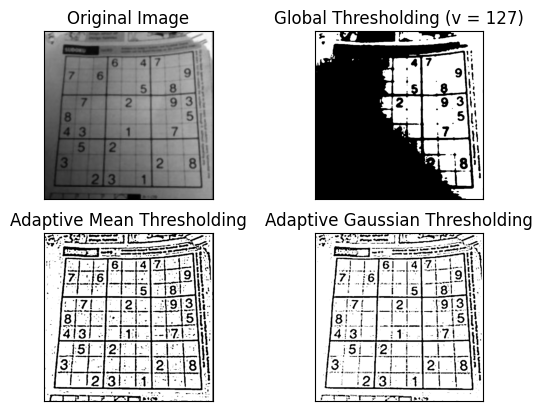

In [5]:
import urllib.request
from PIL import Image
import io
img = cv.imread('D:\\MASTER\\EEE803145 - IP\\LAB\\LAB8\\sudoku.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
img = cv.medianBlur(img,5)
 
ret,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_MEAN_C,\
            cv.THRESH_BINARY,11,2)
th3 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv.THRESH_BINARY,11,2)
 
titles = ['Original Image', 'Global Thresholding (v = 127)',
            'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
images = [img, th1, th2, th3]
 
for i in range(4):
    plt.subplot(2,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

## Otsu's Binarization


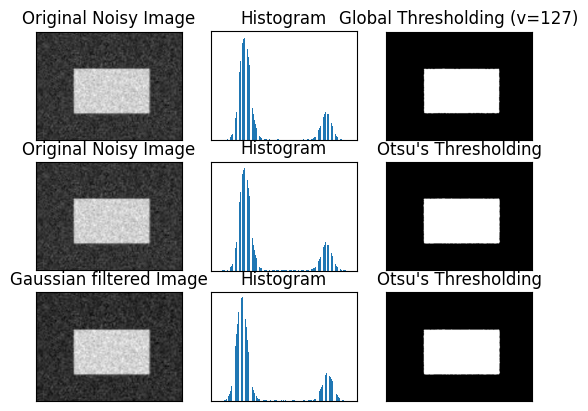

In [6]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
 
img = cv.imread('D:\\MASTER\\EEE803145 - IP\\LAB\\LAB8\\noisy2.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
 
# global thresholding
ret1,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
 
# Otsu's thresholding
ret2,th2 = cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
 
# Otsu's thresholding after Gaussian filtering
blur = cv.GaussianBlur(img,(5,5),0)
ret3,th3 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
 
# plot all the images and their histograms
images = [img, 0, th1,
          img, 0, th2,
          blur, 0, th3]
titles = ['Original Noisy Image','Histogram','Global Thresholding (v=127)',
          'Original Noisy Image','Histogram',"Otsu's Thresholding",
          'Gaussian filtered Image','Histogram',"Otsu's Thresholding"]
 
for i in range(3):
    plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray')
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])
plt.show()